# 1. Linear and quadratic equations: roots, intersections, and minima

Learn to solve a straight-line equation and a quadratic equation, derive the quadratic formula by completing the square, and distinguish a root from a minimum. Prerequisite: [functions and graphs](../../../02_Mathematics_for_ML/04_functions_and_graphs.ipynb). All symbols in the main examples are dimensionless scalars, so you can focus on the algebra before attaching application-specific units. Allow three hours, including the derivation and exercises.

## 2. What problem does this solve?

An equation asks which inputs make a stated equality true. A graph shows those inputs as intersections. A linear equation generally has one solution; a quadratic can have two, one, or no real solutions. Machine learning uses straight lines for simple predictions and quadratic expressions for some error objectives, but solving for a zero is not always the same task as minimizing an error.

Our first goal is to find the roots of an explicitly supplied polynomial. Our second is to locate the minimum of a supplied squared-error-shaped function. Neither task estimates coefficients from a dataset. Later regression lessons will connect these mathematical mechanisms to training.

## 3. Intuition and analogy

Imagine a road drawn above and below sea level. A root is a place where the road crosses or touches sea level. A minimum is its lowest point. The lowest point might lie above sea level, so a minimum can exist even when there are no crossings.

A straight road can cross a level once. A bowl-shaped road can cross twice, touch once, or stay above the level entirely. A quadratic graph is called a parabola. The sign of its squared-term coefficient determines whether the bowl opens upward or downward.

## 4. Terminology

A **polynomial** adds constant multiples of nonnegative whole-number powers. Its **degree** is the largest power with a nonzero coefficient. A **linear equation** in one unknown has degree one. A **quadratic equation** has degree two. A **root** makes a polynomial equal zero. **Factoring** rewrites an expression as a product. The **vertex** is the turning point of a parabola.

The **discriminant** is a coefficient expression that distinguishes the number of real roots. Real numbers include ordinary positive, negative, and fractional values; complex numbers extend them to represent square roots of negative numbers. This lesson's scratch solver reports only real roots. No real roots does not mean no complex roots.

## 5. Mathematical foundations

For $ax+b=0$ with $a\ne0$, subtract $b$ and divide by $a$ to obtain $x=-b/a$. Here $x$ is the unknown; $a$ and $b$ are supplied coefficients. If $a=0$, the equation is constant and requires separate classification.

For a quadratic, use $ax^2+bx+c=0$ with $a\ne0$. Divide by $a$ and complete the square:

$$x^2+\frac{b}{a}x=-\frac ca,$$
$$\left(x+\frac{b}{2a}\right)^2=\frac{b^2-4ac}{4a^2},$$
$$x=\frac{-b\pm\sqrt{b^2-4ac}}{2a}.$$

$a$, $b$, and $c$ are scalar coefficients; $x$ is the scalar unknown. The sign $\pm$ means evaluate both plus and minus branches. Define $D=b^2-4ac$, the discriminant. For real coefficients, $D>0$ gives two distinct real roots, $D=0$ one repeated real root, and $D<0$ no real roots. We added $(b/2a)^2$ to both sides in the middle step, preserving equality. Division by $a$ explains why $a=0$ is excluded.

## 6. Hand-calculated example

For $x^2-5x+6=0$, $a=1$, $b=-5$, and $c=6$. The discriminant is $25-24=1$. The roots are $(5-1)/2=2$ and $(5+1)/2=3$. Factoring gives $(x-2)(x-3)=0$, which independently confirms both values. Substitution gives $4-10+6=0$ and $9-15+6=0$.

Completing the square also gives $x^2-5x+6=(x-2.5)^2-0.25$. A square cannot be negative, so the minimum is -0.25 at input 2.5. That point is different from either root. For $L(w)=(w-3)^2+2$, the minimum is 2 at $w=3$, and there is no real zero at all. $L$ names a supplied objective and $w$ its dimensionless scalar input.

## 7. Implementation from scratch

In [1]:
# Enable embedded figures in this fresh notebook kernel.
from IPython import get_ipython
get_ipython().run_line_magic('matplotlib', 'inline')

In [2]:
import math

def real_quadratic_roots(a, b, c):
    for coefficient in (a, b, c):
        if isinstance(coefficient, bool) or not isinstance(coefficient, (int, float)):
            raise ValueError('Use ordinary finite real coefficients.')
        if not math.isfinite(coefficient):
            raise ValueError('Coefficients must be finite.')
    if a == 0:
        raise ValueError('A quadratic requires a nonzero squared-term coefficient.')
    discriminant = b * b - 4 * a * c
    if discriminant < 0:
        return []
    if discriminant == 0:
        return [-b / (2 * a)]
    root_size = math.sqrt(discriminant)
    return sorted([(-b - root_size) / (2 * a), (-b + root_size) / (2 * a)])

roots = real_quadratic_roots(1, -5, 6)
assert roots == [2.0, 3.0]
assert real_quadratic_roots(1, -4, 4) == [2.0]
assert real_quadratic_roots(1, 0, 1) == []
print('Two-root example:', roots)

Two-root example: [2.0, 3.0]


This directly implements the algebra. It is intentionally not a numerically robust general polynomial solver: extreme magnitudes can overflow, near-zero discriminants are sensitive, and subtracting nearly equal large quantities can lose accuracy. We use small well-behaved coefficients and disclose these limits.

## 8. Inspect intermediate values

In [3]:
a, b, c = 1.0, -5.0, 6.0
discriminant = b ** 2 - 4 * a * c
vertex_x = -b / (2 * a)
vertex_y = a * vertex_x ** 2 + b * vertex_x + c
assert discriminant == 1 and vertex_x == 2.5 and vertex_y == -0.25
for root in roots:
    residual = a * root ** 2 + b * root + c
    assert residual == 0
    print('Root:', root, 'Substitution residual:', residual)
print('Discriminant:', discriminant, 'Vertex:', (vertex_x, vertex_y))

Root: 2.0 Substitution residual: 0.0
Root: 3.0 Substitution residual: 0.0
Discriminant: 1.0 Vertex: (2.5, -0.25)


A residual is the original equation's left side minus its right side. For this zero-right-side equation, it is just the polynomial value. A near-zero residual is evidence of a numerical root; it is not proof that coefficients came from the correct application.

## 9. NumPy library implementation

`np.roots` takes coefficients in descending power order: squared term, linear term, constant. It may return roots in a different order. Sort real roots for comparison here, and explicitly inspect imaginary parts for a no-real-root example. A shape `(3,)` coefficient vector represents three coefficients, not three observations.

In [4]:
import numpy as np
coefficients = np.array([1.0, -5.0, 6.0])
library_roots = np.roots(coefficients)
np.testing.assert_allclose(np.sort(library_roots), roots)
np.testing.assert_allclose(np.polyval(coefficients, library_roots), 0, atol=1e-12)
complex_roots = np.roots([1.0, 0.0, 1.0])
assert np.all(np.abs(complex_roots.imag) > 0)
np.testing.assert_allclose(np.polyval([1, 0, 1], complex_roots), 0, atol=1e-12)
print('Library real roots:', library_roots)
print('Complex roots of x² + 1:', complex_roots)

Library real roots: [3. 2.]
Complex roots of x² + 1: [-0.+1.j  0.-1.j]


The library supports more general polynomials, but finite-precision conditioning still matters. Reporting complex results as real by discarding their imaginary parts would fabricate solutions. Use domain-aware interpretation rather than merely coercing the output type.

## 10. Visualization

The first panel marks the quadratic's two roots and its lower vertex. The second shows an objective with a positive minimum and no root. Keeping the zero reference visible makes the distinction concrete. These are known mathematical rules, not empirical fitted curves.

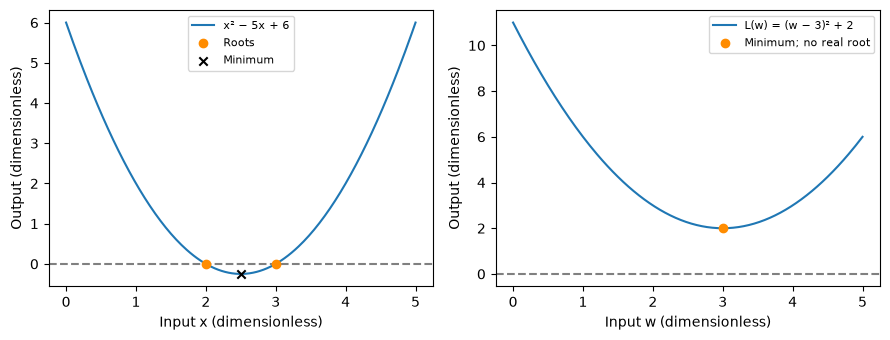

In [5]:
import matplotlib.pyplot as plt
grid = np.linspace(0, 5, 201)
fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))
axes[0].plot(grid, grid ** 2 - 5 * grid + 6, label='x² − 5x + 6')
axes[0].scatter(roots, [0, 0], marker='o', color='darkorange', label='Roots', zorder=3)
axes[0].scatter([2.5], [-0.25], marker='x', color='black', label='Minimum', zorder=3)
axes[1].plot(grid, (grid - 3) ** 2 + 2, label='L(w) = (w − 3)² + 2')
axes[1].scatter([3], [2], color='darkorange', label='Minimum; no real root', zorder=3)
for axis, label in zip(axes, ['Input x', 'Input w']):
    axis.axhline(0, color='gray', linestyle='--')
    axis.set(xlabel=f'{label} (dimensionless)', ylabel='Output (dimensionless)')
    axis.legend(fontsize=8)
fig.tight_layout()
display(fig)
plt.close(fig)

## 11. Experiment: move the constant

Raise the constant from 6 to 6.25 and then 7 while keeping the other coefficients fixed. The parabola shifts upward; its minimum reaches zero and then becomes positive. The discriminant moves from 1 to 0 to -3. The scratch solver should therefore report two, one, and zero real roots.

In [6]:
root_counts = []
for constant in [6.0, 6.25, 7.0]:
    answer = real_quadratic_roots(1.0, -5.0, constant)
    root_counts.append(len(answer))
    print('Constant:', constant, 'Discriminant:', 25 - 4 * constant, 'Real roots:', answer)
assert root_counts == [2, 1, 0]
assert (3 - 3) ** 2 + 2 == 2
assert np.min((grid - 3) ** 2 + 2) == 2

Constant: 6.0 Discriminant: 1.0 Real roots: [2.0, 3.0]
Constant: 6.25 Discriminant: 0.0 Real roots: [2.5]
Constant: 7.0 Discriminant: -3.0 Real roots: []


The grid happens to include three exactly. For an arbitrary minimum, a finite grid may miss the precise location. Completing the square establishes the minimum analytically; sampling a graph only approximates it unless a checked exact point is included.

## 12. Coefficients and computational choices

Coefficients are given, not learned. The plotting interval and numerical tolerance are computational choices rather than model hyperparameters. Choosing a tolerance requires a scale: the same absolute residual may be tiny for one coefficient set and large for another. A relative or scaled residual is useful in more advanced numerical analysis. Do not silently turn every small negative discriminant into zero without a documented error model.

## 13. Evaluation

Check independent factorization, substitution, discriminant classification, library agreement, and validation failures. Compare roots as sets or sorted values rather than depending on solver order. Remember to check admissible input domains in applications: a negative root may solve an equation but be meaningless as a duration or count.

In [7]:
for invalid in [(0, 2, 1), (True, -5, 6), (1, np.nan, 6)]:
    try:
        real_quadratic_roots(*invalid)
    except ValueError:
        pass
    else:
        raise AssertionError('Invalid quadratic coefficients were accepted.')
for root in real_quadratic_roots(2, -10, 12):
    assert math.isclose(2 * root ** 2 - 10 * root + 12, 0, abs_tol=1e-12)
np.testing.assert_allclose(real_quadratic_roots(2, -10, 12), roots)

Multiplying an equation by a nonzero constant preserves its roots. This invariant checks a different property from evaluating the same formula twice. Near-degenerate or extreme-value testing is beyond this intentionally bounded implementation.

## 14. Assumptions and limitations

The scratch function handles real quadratic coefficients and returns only real roots. It rejects linear equations rather than ambiguously treating them as quadratics. For a general model's loss, a closed-form quadratic solution may not exist. A polynomial may also be an inappropriate physical model outside its intended input range. Correct algebra does not justify extrapolating a price, demand, or error relation indefinitely.

## 15. Common mistakes and debugging

Keep the negative sign in $b=-5$ when calculating both $b^2$ and $-b$. Put the entire numerator over $2a$ in code; `(-b + sqrt_D) / (2*a)` is different from `-b + sqrt_D / 2*a`. Do not confuse roots with the vertex. Do not conclude that an objective cannot be minimized because its minimum is greater than zero.

If a library disagrees, check coefficient order, real versus complex output, and scale before increasing tolerances. Replacing NaN with zero inside an algebraic solver changes the problem and can invent roots.

## 16. Alternatives

Factoring is transparent when small integer factors exist. Completing the square explains the vertex and derives the formula. The quadratic formula handles many cases directly. Numerical polynomial solvers help more general degrees, while numerical root-finding seeks zeros without assuming a polynomial. Optimization seeks minima and needs its own conditions and methods.

## 17. Exercises

- **Beginner:** Solve $3x+6=0$ and verify the result.
- **Beginner:** Factor $x^2-7x+12$ and find its roots.
- **Beginner:** Classify the real roots of $x^2+2x+1$ and $x^2+2x+2$ using discriminants.
- **Intermediate:** Complete the square for $x^2-6x+11$ and identify its minimum and real-root count.
- **Intermediate:** Explain why multiplying all coefficients by five preserves roots but changes polynomial output values.
- **Challenge:** Implement a dispatcher for $ax^2+bx+c=0$ that distinguishes quadratic, linear, all-real-values, and no-solution cases. Return an explicit kind as well as roots and test each branch.

## 18. Detailed solutions

The linear solution is minus two. The factored quadratic is $(x-3)(x-4)$, so roots are three and four. Discriminants are zero and minus four; the first has one repeated root at minus one and the second has no real roots. Completing the square gives $(x-3)^2+2$, with minimum two at three and no real zero. Scaling an equation scales zero to zero while changing nonzero output heights.

The dispatcher below uses `a=0` to select linear behavior. If both variable coefficients vanish, the remaining constant determines whether every real input or none is a solution. An empty root list alone would fail to distinguish those meanings.

In [8]:
def solve_real_polynomial(a, b, c):
    if any(isinstance(v, bool) or not isinstance(v, (int, float)) or not math.isfinite(v) for v in (a, b, c)):
        raise ValueError('Use finite ordinary numeric coefficients.')
    if a != 0:
        found = real_quadratic_roots(a, b, c)
        return {'kind': 'quadratic real roots' if found else 'no real solution', 'roots': found}
    if b != 0:
        return {'kind': 'linear', 'roots': [-c / b]}
    return {'kind': 'all real values' if c == 0 else 'no real solution', 'roots': []}

assert 3 * (-2) + 6 == 0
assert real_quadratic_roots(1, -7, 12) == [3.0, 4.0]
assert real_quadratic_roots(1, 2, 1) == [-1.0]
assert real_quadratic_roots(1, 2, 2) == []
assert solve_real_polynomial(0, 3, 6) == {'kind': 'linear', 'roots': [-2.0]}
assert solve_real_polynomial(0, 0, 0)['kind'] == 'all real values'
assert solve_real_polynomial(0, 0, 2)['kind'] == 'no real solution'
assert solve_real_polynomial(1, 0, 1)['kind'] == 'no real solution'
assert solve_real_polynomial(1, -7, 12)['roots'] == [3.0, 4.0]
print('All polynomial classification branches passed.')

All polynomial classification branches passed.


## 19. Knowledge check

**What is a root?** An input making the polynomial equal zero.

**What does a negative discriminant mean here?** No real roots; complex roots may still exist.

**Why exclude a zero squared coefficient?** The equation is no longer quadratic and needs another branch.

**Is a minimum necessarily a root?** No. Its output can be positive or negative.

**Why substitute solutions back?** It independently checks whether the original equality is satisfied.

## 20. Interview preparation

**How do roots and optimization differ?** Root-finding seeks zero output; optimization seeks an extremum, which may have nonzero output.

**What does completing the square reveal?** A quadratic's vertex and a route to the root formula without relying on memorization.

**Why can a direct quadratic formula lose precision?** Subtraction of nearly equal floating-point terms can erase significant digits.

**How should a solver report degenerate cases?** Explicitly distinguish unique finite roots, infinitely many solutions, and no solution.

**Does library agreement prove a real-world model is valid?** No. It checks computation under supplied coefficients, not the suitability of the relation or its domain.

## 21. Summary and next steps

Solve equations by valid algebra and check them by substitution. Use the discriminant to understand real-root cases and keep roots separate from minima. Continue to [logarithms and exponentials](../../../02_Mathematics_for_ML/06_logarithms_and_exponentials.ipynb), which explain multiplicative change and its inverse.